### step 1 : Download the data

In [1]:
import os
from pathlib import Path
import zipfile, kaggle
path=Path('titanic')
kaggle.api.competition_download_cli(str(path))
zipfile.ZipFile(f'{path}.zip').extractall(path)

titanic.zip: Skipping, found more recently modified local copy (use --force to force download)


In [2]:
for f in path.iterdir():
    print(f)

titanic/test.csv
titanic/train.csv
titanic/gender_submission.csv


Numby : Array Calc
Pytourch : Deep Learning Framework
Pandas : For Data Analysis

### step 2 : Importing the libraries

In [3]:
import torch, numpy as np, pandas as pd
np.set_printoptions(linewidth=140)
torch.set_printoptions(linewidth=140, sci_mode=False, edgeitems=7)
pd.set_option('display.width', 140)

### step 3 : Cleaning the data

Data is in form of tables,
Provided CSV,
Open it using pandas lib which will provide dataFrame.

In [4]:
df=pd.read_csv(path/'train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Here some columns are with Nan values, we need to handle those values before feeding the data to model.Until that we can't multiple the data with model parameters.

isna() : to check the null values in the dataFrame.
fillna() : to fill the null values with some value.


In [5]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

i.e. There are 3 columns which has Nan values and Cabin is having high number of null values, 

replace the missing values with mode function which will return the most repeated value in the column.
but it returns more than one rows if there is a tie. In such cases, we can use the first value(first row) returned by the mode function.

In [6]:
modes= df.mode().iloc[0]
modes

PassengerId                      1
Survived                       0.0
Pclass                         3.0
Name           Abbing, Mr. Anthony
Sex                           male
Age                           24.0
SibSp                          0.0
Parch                          0.0
Ticket                        1601
Fare                          8.05
Cabin                      B96 B98
Embarked                         S
Name: 0, dtype: object

In [7]:
# Now we now what are the Ages,Cabin and and Embarked  repeated values
df.fillna(modes, inplace=True)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,B96 B98,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,B96 B98,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,B96 B98,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,B96 B98,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,B96 B98,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [8]:
#verify 
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

quick summary of the numeric column in the dataset

In [9]:
import numpy as np
df.describe(include=(np.number))

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,28.566970,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.199572,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,24.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Here values are very uneven.
like fare Values starting from 0 to 30 as well. 
So these values will create the problem when each column will be multiplied by a coefficient in the model. So we need to scale the data before feeding it to the model.
We can see it by histogram as well --> best practice 

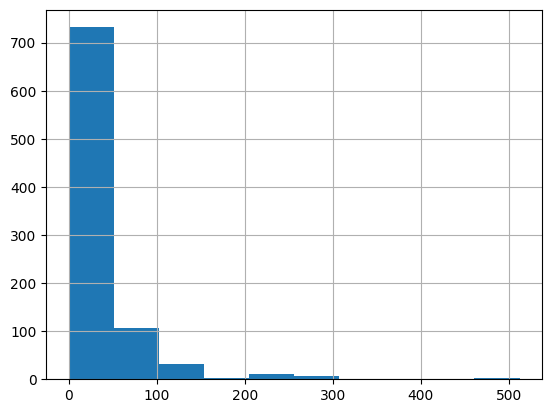

In [10]:
df['Fare'].hist();

linkcode
To fix this, the most common approach is to take the logarithm, which squishes the big numbers and makes the distribution more reasonable. Note, however, that there are zeros in the Fare column, and log(0) is infinite -- to fix this, we'll simply add 1 to all values first:

In [11]:
df['LogFare'] = np.log(df['Fare']+1)

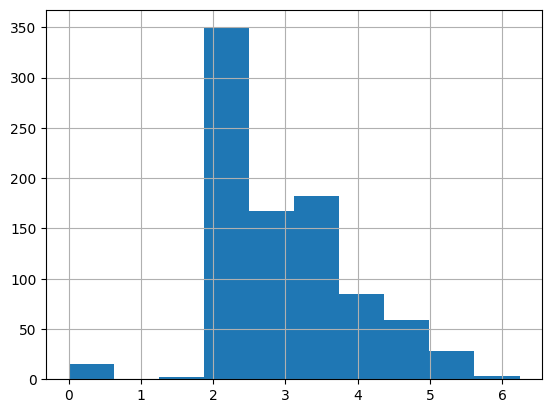

In [12]:
df['LogFare'].hist();

In [13]:
pclasses = sorted(df.Pclass.unique())
pclasses

[np.int64(1), np.int64(2), np.int64(3)]

Summary about the numeric columns in the dataset after log transformation. We can see that the values are more evenly distributed now.

In [14]:
df.describe(include=['str'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,891
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,691,646


As we need to multiple each column by a coefficient in the model but here like Sex is male and Embarked is S in some rows which can't be multiple with the coefficient so we need to convert these categorical values into numeric values. We can do this by using the get_dummies() function in pandas which will create a new column for each unique value in the column and will fill it with 1 or 0 depending on whether the value is present in the row or not.

In [15]:
df = pd.get_dummies(df, columns=["Sex","Pclass","Embarked"], dtype=int)
df.columns


Index(['PassengerId', 'Survived', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'LogFare', 'Sex_female', 'Sex_male',
       'Pclass_1', 'Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='str')

In [16]:
#Here's what the first few rows of those newly added columns look like:
added_cols = ['Sex_male', 'Sex_female', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Embarked_C', 'Embarked_Q', 'Embarked_S']
df[added_cols].head()

,Sex_male,Sex_female,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
0,1,0,0,0,1,0,0,1
1,0,1,1,0,0,1,0,0
2,0,1,0,0,1,0,0,1
3,0,1,1,0,0,0,0,1
4,1,0,0,0,1,0,0,1



Now we can create our independent (predictors) and dependent (target) variables. They both need to be PyTorch tensors. Our dependent variable is Survived:
Dependent variable (target) = what you want to predict → Survived (0 or 1)
Independent variables (predictors) = the inputs used to make the prediction → Age, Fare, Sex_male, Pclass_1, etc.

Input (Age, Sex, Fare...) → Model → Output (Survived?)

Why PyTorch tensors?

PyTorch models only understand tensors — they can't work directly with Pandas DataFrames. Tensors are like NumPy arrays but with extra GPU/math capabilities needed for deep learning.

So the flow is:
Pandas DataFrame → convert → PyTorch Tensor → feed into Model



In [17]:
from torch import tensor
#target dependent
t_dep = tensor(df.Survived)


Continuous variables = columns with actual numeric values that can be any number:

Age (22.0, 35.0, 26.0...)
LogFare (1.5, 3.2, 2.1...)
Dummy variables = the 0/1 columns we just created with get_dummies:

Sex_male, Sex_female
Pclass_1, Pclass_2, Pclass_3
Embarked_C, Embarked_Q, Embarked_S
Why not all columns?

Some columns are not useful for the model:

PassengerId — just a row number, meaningless
Name — text, too unique to learn from
Ticket — random string
Cabin — too many missing values
Survived — that's your target, not an input
So "independent variables" = only the columns that are meaningful numbers the model can learn from:


indep_cols = ['Age', 'SibSp', 'Parch', 'LogFare',   # continuous
              'Sex_male', 'Sex_female',                # dummy
              'Pclass_1', 'Pclass_2', 'Pclass_3',     # dummy
              'Embarked_C', 'Embarked_Q', 'Embarked_S'] # dummy
              
In short: pick only the columns that carry useful information for predicting survival.

In [65]:
indep_cols = ['Age', 'SibSp', 'Parch', 'LogFare'] + added_cols

t_indep = tensor(df[indep_cols].values, dtype=torch.float)
t_indep

tensor([[22.0000,  1.0000,  0.0000,  2.1102,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [38.0000,  1.0000,  0.0000,  4.2806,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000],
        [26.0000,  0.0000,  0.0000,  2.1889,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [35.0000,  1.0000,  0.0000,  3.9908,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000],
        [35.0000,  0.0000,  0.0000,  2.2028,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [24.0000,  0.0000,  0.0000,  2.2469,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000],
        [54.0000,  0.0000,  0.0000,  3.9677,  1.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000],
        ...,
        [25.0000,  0.0000,  0.0000,  2.0857,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000],
        [39.0000,  0.0000,  5.0000,  3.4054

Number of rows and columns for independent variables 

In [19]:
t_indep.shape

torch.Size([891, 12])

So now we have a matrix of independent variables and a dependent variable vector, we can work on calculating our predictions and our losses 
Matrix of Independent Variable like: 
Age  LogFare  Sex_male  Sex_female  Pclass_1  Pclass_2  ...
22.0   2.1      1         0           0         0
38.0   4.3      0         1           1         0
26.0   2.2      0         1           0         0
...
and Dependent variable vector : is a 1D vector with survival data 
[0, 1, 1, 1, 0, 0, 1, 0, ...]   ← one value per passenger

so shape is 891*12



### Setting up a linear model

Our first model will be a simple linear model. We'll need a coefficient for each column in t_indep. We'll pick random numbers in the range (-0.5,0.5), and set our manual seed so that my explanations in the prose in this notebook will be consistent with what you see when you run it.

line

In [20]:
torch.manual_seed(442) #Fixes randomness
n_coeff = t_indep.shape[1] #n_coeff = 12
coeffs = torch.rand(n_coeff)-0.5 # 12 random numbers between -0.5 and 0.5
coeffs

tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,  0.2799, -0.4392,  0.2103,  0.3625])

In [21]:
t_indep*coeffs


tensor([[-10.1838,   0.1386,   0.0000,  -0.4772,  -0.2632,  -0.0000,   0.0000,   0.0000,   0.2799,  -0.0000,   0.0000,   0.3625],
        [-17.5902,   0.1386,   0.0000,  -0.9681,  -0.0000,  -0.3147,   0.4876,   0.0000,   0.0000,  -0.4392,   0.0000,   0.0000],
        [-12.0354,   0.0000,   0.0000,  -0.4950,  -0.0000,  -0.3147,   0.0000,   0.0000,   0.2799,  -0.0000,   0.0000,   0.3625],
        [-16.2015,   0.1386,   0.0000,  -0.9025,  -0.0000,  -0.3147,   0.4876,   0.0000,   0.0000,  -0.0000,   0.0000,   0.3625],
        [-16.2015,   0.0000,   0.0000,  -0.4982,  -0.2632,  -0.0000,   0.0000,   0.0000,   0.2799,  -0.0000,   0.0000,   0.3625],
        [-11.1096,   0.0000,   0.0000,  -0.5081,  -0.2632,  -0.0000,   0.0000,   0.0000,   0.2799,  -0.0000,   0.2103,   0.0000],
        [-24.9966,   0.0000,   0.0000,  -0.8973,  -0.2632,  -0.0000,   0.4876,   0.0000,   0.0000,  -0.0000,   0.0000,   0.3625],
        ...,
        [-11.5725,   0.0000,   0.0000,  -0.4717,  -0.2632,  -0.0000,   0.0000


We can see we've got a problem here. The sums of each row will be dominated by the first column, which is Age, since that's bigger on average than all the others.

Let's make all the columns contain numbers from 0 to 1, by dividing each column by its max():

In [22]:
vals,indices = t_indep.max(dim=0)
t_indep = t_indep / vals #Broadcasting

### Broadcasting :
 In short, this acts as if there's a separate copy of the vector for every row of the matrix, so it divides each row of the matrix by the vector. In practice, it doesn't actually make any copies, and does the whole thing in a highly optimized way, taking full advantage of modern CPUs (or, indeed, GPUs, if we're using them). Broadcasting is one of the most important techniques for making your code concise, maintainable, and fast, so it's well worth studying and practicing.

In [23]:
t_indep*coeffs

tensor([[-0.1273,  0.0173,  0.0000, -0.0765, -0.2632, -0.0000,  0.0000,  0.0000,  0.2799, -0.0000,  0.0000,  0.3625],
        [-0.2199,  0.0173,  0.0000, -0.1551, -0.0000, -0.3147,  0.4876,  0.0000,  0.0000, -0.4392,  0.0000,  0.0000],
        [-0.1504,  0.0000,  0.0000, -0.0793, -0.0000, -0.3147,  0.0000,  0.0000,  0.2799, -0.0000,  0.0000,  0.3625],
        [-0.2025,  0.0173,  0.0000, -0.1446, -0.0000, -0.3147,  0.4876,  0.0000,  0.0000, -0.0000,  0.0000,  0.3625],
        [-0.2025,  0.0000,  0.0000, -0.0798, -0.2632, -0.0000,  0.0000,  0.0000,  0.2799, -0.0000,  0.0000,  0.3625],
        [-0.1389,  0.0000,  0.0000, -0.0814, -0.2632, -0.0000,  0.0000,  0.0000,  0.2799, -0.0000,  0.2103,  0.0000],
        [-0.3125,  0.0000,  0.0000, -0.1438, -0.2632, -0.0000,  0.4876,  0.0000,  0.0000, -0.0000,  0.0000,  0.3625],
        ...,
        [-0.1447,  0.0000,  0.0000, -0.0756, -0.2632, -0.0000,  0.0000,  0.0000,  0.2799, -0.0000,  0.0000,  0.3625],
        [-0.2257,  0.0000,  0.2008, -0.1234

preds = (t_indep*coeffs).sum(axis=1) 

multiply each column by its coefficient
| Age×c1 | LogFare×c2 | Sex_male×c3 | Sex_female×c4 |
|--------|------------|-------------|---------------|
| 5.29   | -0.82      | 0.12        | 0.0           |
| 8.74   | -1.73      | 0.0         | 0.12          |

.sum(axis=1) → add all values across each row
passenger 1 → 5.29 + (-0.82) + 0.12 + 0.0 + ... = single number
passenger 2 → 8.74 + (-1.73) + 0.0 + 0.12 + ... = single number



In [24]:
preds = (t_indep*coeffs).sum(axis=1)
preds[:10]

tensor([ 0.1927, -0.6239,  0.0979,  0.2056,  0.0968,  0.0066,  0.1306,  0.3476,  0.1613, -0.6285])

This prediction is useless : 
Our coefficients are random → predictions are just random numbers, not real survival predictions.
Loss function comes into picture
What is a Loss Function?: 
 measures how wrong your predictions are. Lower loss = better model.
 Mean Absolute Error (MAE):loss = average of |prediction - actual|


Passenger	Actual	Predicted	Error (absolute)
1	1	0.42	|0.42-1| = 0.58
2	0	0.78	|0.78-0| = 0.78
3	1	-0.31	|-0.31-1| = 1.31
Loss = (0.58 + 0.78 + 1.31) / 3 = 0.89


What is Gradient Descent? : 
A process to reduce the loss by adjusting coefficients:

Step	Action
1	Make predictions with current coefficients
2	Calculate loss (how wrong we are)
3	Adjust coefficients slightly to reduce loss
4	Repeat until loss is small

In [25]:
#Calculate the loss
loss = torch.abs(preds-t_dep).mean()
loss

tensor(0.5382)

As we know how to calculate the prediction and loss,  so make two helper function to calc_pred and cal_loss because these functions need to be apply number of times through out the process 


In [26]:
def calc_preds(coeffs, indeps):
    return (indeps*coeffs).sum(axis=1)
def calc_loss(coeffs, indeps, deps):
    return torch.abs(calc_preds(coeffs, indeps)-deps).mean()

### Doing a gradient descent step
coeffs.requires_grad_() tells PyTorch:

"Track all math operations done on coeffs so we can calculate gradients later."

Why do we need it?

To do gradient descent, we need to know:

How much to change each coefficient
Which direction to change it (increase or decrease)
This is calculated using gradients (calculus derivatives).

PyTorch doesn't track gradients by default → you have to explicitly turn it on with requires_grad_().
What happens without it:

Without requires_grad_()	With requires_grad_()
PyTorch forgets all math operations	PyTorch remembers all math operations
Can't calculate gradients	Can calculate gradients
Can't update coefficients	Can update coefficients
No learning possible	Learning possible ✓

In [27]:
# lets do one epoch
coeffs.requires_grad_()

tensor([-0.4629,  0.1386,  0.2409, -0.2262, -0.2632, -0.3147,  0.4876,  0.3136,  0.2799, -0.4392,  0.2103,  0.3625], requires_grad=True)

Now when we calculate our loss, PyTorch will keep track of all the steps, so we'll be able to get the gradients afterwards:

In [28]:
loss = calc_loss(coeffs, t_indep, t_dep)
loss

tensor(0.5382, grad_fn=<MeanBackward0>)

In [29]:
#Use backward() to ask PyTorch to calculate gradients now:
loss.backward()


In [30]:
coeffs.grad

tensor([-0.0106,  0.0129, -0.0041, -0.0484,  0.2099, -0.2132, -0.1212, -0.0247,  0.1425, -0.1886, -0.0191,  0.2043])

In [31]:
loss = calc_loss(coeffs, t_indep, t_dep)
loss.backward()
coeffs.grad

tensor([-0.0212,  0.0258, -0.0082, -0.0969,  0.4198, -0.4265, -0.2424, -0.0494,  0.2851, -0.3771, -0.0382,  0.4085])

Note that each time we call backward, the gradients are actually added to whatever is in the .grad attribute. Let's try running the above steps again:

In [32]:
loss = calc_loss(coeffs, t_indep, t_dep)
loss.backward()
with torch.no_grad():
    coeffs.sub_(coeffs.grad * 0.1)
    coeffs.grad.zero_()
    print(calc_loss(coeffs, t_indep, t_dep))

tensor(0.4945)


As you see, our .grad values are have doubled. That's because it added the gradients a second time. For this reason, after we use the gradients to do a gradient descent step, we need to set them back to zero.

We can now do one gradient descent step, and check that our loss decreases

One Step of Gradient Descent

What is Gradient Descent?
A process to improve model by reducing loss (error) step by step.

Step 1: Calculate Loss


loss = calc_loss(coeffs, t_indep, t_dep)
Measures how wrong current predictions are. Returns a single number (e.g. 0.89)

Step 2: Calculate Gradients


loss.backward()
PyTorch automatically calculates:

How much each coefficient contributed to the error
Which direction to adjust each coefficient
Stores result in coeffs.grad
Step 3: Update Coefficients


coeffs.sub_(coeffs.grad * 0.1)
coeffs.grad → direction & amount to change
0.1 → learning rate (step size, keep it small)
.sub_() → subtract to move in right direction
Formula: new_coeff = old_coeff - (gradient × learning_rate)

Step 4: Reset Gradients


coeffs.grad.zero_()
PyTorch adds up gradients by default, so we must reset to zero before next step. Otherwise gradients will be wrong.

Step 5: Verify Improvement


print(calc_loss(coeffs, t_indep, t_dep))
New loss should be lower than before → model improved!

Why torch.no_grad()?
Steps 3 & 4 are wrapped in torch.no_grad() because we are updating coefficients, not training. This prevents PyTorch from recording these operations unnecessarily.

Summary:

Calculate loss → find gradients → update coefficients → reset gradients → repeat until loss is minimized



### Training the linear model

linkcode
Before we begin training our model, we'll need to ensure that we hold out a validation set for calculating our metrics

In [33]:
from fastai.data.transforms import RandomSplitter
trn_split,val_split=RandomSplitter(seed=42)(df)

Now we can apply those indicies to our independent and dependent variables:

In [34]:
trn_indep,val_indep = t_indep[trn_split],t_indep[val_split]
trn_dep,val_dep = t_dep[trn_split],t_dep[val_split]
len(trn_indep),len(val_indep)

(713, 178)

We'll create functions for the three things we did manually above: updating coeffs, doing one full gradient descent step, and initilising coeffs to random numbers:

In [35]:
def update_coeffs(coeffs, lr):
    coeffs.sub_(coeffs.grad * lr)
    coeffs.grad.zero_()

In [36]:
def one_epoch(coeffs, lr):
    loss = calc_loss(coeffs, trn_indep, trn_dep)
    loss.backward()
    with torch.no_grad(): update_coeffs(coeffs, lr)
    print(f"{loss:.3f}", end="; ")

In [37]:
def init_coeffs(): return (torch.rand(n_coeff)-0.5).requires_grad_()

We can now use these functions to train our model:

In [71]:
def train_model(epochs=30, lr=0.01):
    torch.manual_seed(442)
    coeffs = init_coeffs()
    for i in range(epochs): one_epoch(coeffs, lr=lr)
    return coeffs

In [72]:
#et's try it. Our loss will print at the end of every step, so we hope we'll see it going down:
coeffs = train_model(18, lr=0.2)

0.521; 0.496; 0.475; 0.461; 0.447; 0.433; 0.419; 0.405; 0.392; 0.379; 0.367; 0.357; 0.348; 0.339; 0.331; 0.323; 0.315; 0.307; 

Let's take a look at the coefficients for each column:

In [40]:
def show_coeffs(): return dict(zip(indep_cols, coeffs.requires_grad_(False)))
show_coeffs()

{'Age': tensor(-0.2694),
 'SibSp': tensor(0.0901),
 'Parch': tensor(0.2359),
 'LogFare': tensor(0.0280),
 'Sex_male': tensor(-0.3990),
 'Sex_female': tensor(0.2345),
 'Pclass_1': tensor(0.7232),
 'Pclass_2': tensor(0.4112),
 'Pclass_3': tensor(0.3601),
 'Embarked_C': tensor(0.0955),
 'Embarked_Q': tensor(0.2395),
 'Embarked_S': tensor(0.2122)}

### Measuring accuracy

the proportion of rows where we correctly predict survival. Let's see how accurate we were on the validation set. First, calculate the predictions:

In [41]:

preds = calc_preds(coeffs, val_indep)

In [42]:
results = val_dep.bool()==(preds>0.5)
results[:16]

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True, False, False, False,  True,  True, False])

In [43]:
results.float().mean()


tensor(0.7865)

That's not a bad start at all! We'll create a function so we can calcuate the accuracy easy for other models we train

In [44]:
def acc(coeffs): return (val_dep.bool()==(calc_preds(coeffs, val_indep)>0.5)).float().mean()
acc(coeffs)

tensor(0.7865)

### Using sigmoid

Looking at our predictions, there's one obvious problem -- some of our predictions of the probability of survival are >1, and some are <0:

Sigmoid help us to bring these prediction between 0 to 1

In [45]:
preds[:28]

tensor([ 0.8160,  0.1295, -0.0148,  0.1831,  0.1520,  0.1350,  0.7279,  0.7754,  0.3222,  0.6740,  0.0753,  0.0389,  0.2216,  0.7631,
         0.0678,  0.3997,  0.3324,  0.8278,  0.1078,  0.7126,  0.1023,  0.3627,  0.9937,  0.8050,  0.1153,  0.1455,  0.8652,  0.3425])

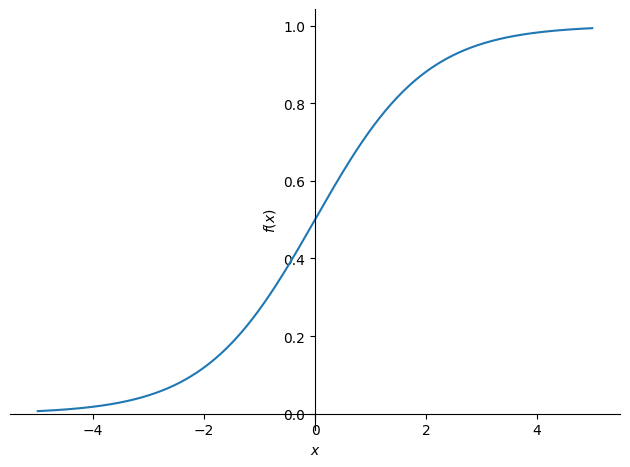

In [46]:
#Lets see how Sigmoid will looks like
import sympy
x = sympy.Symbol('x')
sympy.plot(1/(1+sympy.exp(-x)), (x, -5, 5));

 by pytorch is already there a sigmoid for us we will be using 
accordingly we can modify the calc_preds as follows


In [47]:
def calc_preds(coeffs, indeps): return torch.sigmoid((indeps*coeffs).sum(axis=1))

#### Lets Train Again   
Let's train a new model now, using this updated function to calculate predictions:

In [48]:
coeffs = train_model(lr=100)

0.510; 0.327; 0.294; 0.207; 0.201; 0.199; 0.198; 0.197; 0.196; 0.196; 0.196; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.195; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 0.194; 

In [49]:
acc(coeffs)

tensor(0.8258)

In [50]:
show_coeffs()

{'Age': tensor(-1.5061),
 'SibSp': tensor(-1.1575),
 'Parch': tensor(-0.4267),
 'LogFare': tensor(0.2543),
 'Sex_male': tensor(-10.3320),
 'Sex_female': tensor(8.4185),
 'Pclass_1': tensor(3.8389),
 'Pclass_2': tensor(2.1398),
 'Pclass_3': tensor(-6.2331),
 'Embarked_C': tensor(1.4771),
 'Embarked_Q': tensor(2.1168),
 'Embarked_S': tensor(-4.7958)}

###  Deep learning


The neural net in the previous section only uses one hidden layer, so it doesn't count as "deep" learning. But we can use the exact same technique to make our neural net deep, by adding more matrix multiplications.

First, we'll need to create additional coefficients for each layer:

In [59]:
trn_dep = trn_dep[:,None]
val_dep = val_dep[:,None]

In [60]:
def init_coeffs():
    hiddens = [10, 10]  # <-- set this to the size of each hidden layer you want
    sizes = [n_coeff] + hiddens + [1]
    n = len(sizes)
    layers = [(torch.rand(sizes[i], sizes[i+1])-0.3)/sizes[i+1]*4 for i in range(n-1)]
    consts = [(torch.rand(1)[0]-0.5)*0.1 for i in range(n-1)]
    for l in layers+consts: l.requires_grad_()
    return layers,consts

Our deep learning calc_preds looks much the same as before, but now we loop through each layer, instead of listing them separately:

In [61]:
import torch.nn.functional as F

def calc_preds(coeffs, indeps):
    layers,consts = coeffs
    n = len(layers)
    res = indeps
    for i,l in enumerate(layers):
        res = res@l + consts[i]
        if i!=n-1: res = F.relu(res)
    return torch.sigmoid(res)

We also need a minor update to update_coeffs since we've got layers and consts separated now

In [62]:
def update_coeffs(coeffs, lr):
    layers,consts = coeffs
    for layer in layers+consts:
        layer.sub_(layer.grad * lr)
        layer.grad.zero_()

Again train the model


In [78]:
coeffs = train_model(lr=100)

0.521; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.377; 0.377; 0.377; 0.377; 0.377; 0.376; 0.375; 0.374; 0.372; 0.366; 0.346; 

That's improved too! Here's the coefficients of our trained model:

In [79]:
acc(coeffs)

tensor(0.7640)

## A neural network

We've now got what we need to implement our neural network.

First, we'll need to create coefficients for each of our layers. Our first set of coefficients will take our `n_coeff` inputs, and create `n_hidden` outputs. We can choose whatever `n_hidden` we like -- a higher number gives our network more flexibility, but makes it slower and harder to train. So we need a matrix of size `n_coeff` by `n_hidden`. We'll divide these coefficients by `n_hidden` so that when we sum them up in the next layer we'll end up with similar magnitude numbers to what we started with.

Then our second layer will need to take the `n_hidden` inputs and create a single output, so that means we need a `n_hidden` by `1` matrix there. The second layer will also need a constant term added.

In [81]:
def init_coeffs(n_hidden=20):
    layer1 = (torch.rand(n_coeff, n_hidden)-0.5)/n_hidden
    layer2 = torch.rand(n_hidden, 1)-0.3
    const = torch.rand(1)[0]
    return layer1.requires_grad_(),layer2.requires_grad_(),const.requires_grad_()

Now we have our coefficients, we can create our neural net. The key steps are the two matrix products, `indeps@l1` and `res@l2` (where `res` is the output of the first layer). The first layer output is passed to `F.relu` (that's our non-linearity), and the second is passed to `torch.sigmoid` as before.

In [82]:
import torch.nn.functional as F

def calc_preds(coeffs, indeps):
    l1,l2,const = coeffs
    res = F.relu(indeps@l1)
    res = res@l2 + const
    return torch.sigmoid(res)

Finally, now that we have more than one set of coefficients, we need to add a loop to update each one:

In [83]:
def update_coeffs(coeffs, lr):
    for layer in coeffs:
        layer.sub_(layer.grad * lr)
        layer.grad.zero_()

In [84]:
coeffs = train_model(lr=1.4)

0.543; 0.532; 0.520; 0.505; 0.487; 0.466; 0.439; 0.407; 0.373; 0.343; 0.319; 0.301; 0.286; 0.274; 0.264; 0.256; 0.250; 0.245; 0.240; 0.237; 0.234; 0.231; 0.229; 0.227; 0.226; 0.224; 0.223; 0.222; 0.221; 0.220; 

In [85]:
coeffs = train_model(lr=20)

0.543; 0.400; 0.260; 0.390; 0.221; 0.211; 0.197; 0.195; 0.193; 0.193; 0.193; 0.193; 0.193; 0.193; 0.193; 0.193; 0.193; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 0.192; 

In [86]:
acc(coeffs)

tensor(0.8258)

In this case our neural net isn't showing better results than the linear model. That's not surprising; this dataset is very small and very simple, and isn't the kind of thing we'd expect to see neural networks excel at. Furthermore, our validation set is too small to reliably see much accuracy difference. But the key thing is that we now know exactly what a real neural net looks like!

## Deep learning

The neural net in the previous section only uses one hidden layer, so it doesn't count as "deep" learning. But we can use the exact same technique to make our neural net deep, by adding more matrix multiplications.

First, we'll need to create additional coefficients for each layer:

In [87]:
def init_coeffs():
    hiddens = [10, 10]  # <-- set this to the size of each hidden layer you want
    sizes = [n_coeff] + hiddens + [1]
    n = len(sizes)
    layers = [(torch.rand(sizes[i], sizes[i+1])-0.3)/sizes[i+1]*4 for i in range(n-1)]
    consts = [(torch.rand(1)[0]-0.5)*0.1 for i in range(n-1)]
    for l in layers+consts: l.requires_grad_()
    return layers,consts

You'll notice here that there's a lot of messy constants to get the random numbers in just the right ranges. When you train the model in a moment, you'll see that the tiniest changes to these initialisations can cause our model to fail to train at all! This is a key reason that deep learning failed to make much progress in the early days -- it's very finicky to get a good starting point for our coefficients. Nowadays, we have ways to deal with that, which we'll learn about in other notebooks.

Our deep learning `calc_preds` looks much the same as before, but now we loop through each layer, instead of listing them separately:

In [88]:
import torch.nn.functional as F

def calc_preds(coeffs, indeps):
    layers,consts = coeffs
    n = len(layers)
    res = indeps
    for i,l in enumerate(layers):
        res = res@l + consts[i]
        if i!=n-1: res = F.relu(res)
    return torch.sigmoid(res)

We also need a minor update to `update_coeffs` since we've got `layers` and `consts` separated now:

In [89]:
def update_coeffs(coeffs, lr):
    layers,consts = coeffs
    for layer in layers+consts:
        layer.sub_(layer.grad * lr)
        layer.grad.zero_()

In [90]:
#Train Our model
coeffs = train_model(lr=4)

0.521; 0.483; 0.427; 0.379; 0.379; 0.379; 0.379; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.378; 0.377; 0.376; 0.371; 0.333; 0.239; 0.224; 0.208; 0.204; 0.203; 0.203; 0.207; 0.197; 0.196; 0.195; 

In [91]:
acc(coeffs)

tensor(0.8258)

## Final thoughts

It's actually pretty cool that we've managed to create a real deep learning model from scratch and trained it to get over 80% accuracy on this task, all in the course of a single notebook!

The "real" deep learning models that are used in research and industry look very similar to this, and in fact if you look inside the source code of any deep learning model you'll recognise the basic steps are the same.

The biggest differences in practical models to what we have above are:

- How initialisation and normalisation is done to ensure the model trains correctly every time
- Regularization (to avoid over-fitting)
- Modifying the neural net itself to take advantage of knowledge of the problem domain
- Doing gradient descent steps on smaller batches, rather than the whole dataset.
